## Import Libraries

In [60]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import seaborn as sns

# Stats
from scipy import stats
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

%matplotlib inline

In [3]:
DATA_PATH = "../data-visualization/cleaned_master_order_table1.csv"

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

In [4]:
df=pd.read_csv("../data-visualization/cleaned_master_order_table1.csv")
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,review_score,review_risk_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,4.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,4.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,5.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,5.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,5.0,False


In [5]:
print("------Shape of the DataFrame------")
print(df.shape)
print("------Printing basic information------")
print(df.info())
print("------Printing basic descriptive statistics------")
print(df.describe(include=[np.number]))
print("------looking for null values in columns------")
print(df.isna().sum())

------Shape of the DataFrame------
(95830, 14)
------Printing basic information------
<class 'pandas.DataFrame'>
RangeIndex: 95830 entries, 0 to 95829
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       95830 non-null  str           
 1   customer_id                    95830 non-null  str           
 2   customer_unique_id             95830 non-null  str           
 3   order_status                   95830 non-null  str           
 4   order_purchase_timestamp       95830 non-null  datetime64[us]
 5   order_approved_at              95816 non-null  datetime64[us]
 6   order_delivered_carrier_date   95829 non-null  datetime64[us]
 7   order_delivered_customer_date  95830 non-null  datetime64[us]
 8   order_estimated_delivery_date  95830 non-null  datetime64[us]
 9   customer_zip_code_prefix       95830 non-null  int64         
 10  custome

### Check the data across all columns of NUll values at Order approved at columns

In [6]:
df[df["order_approved_at"].isna()][
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
5141,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33
16016,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06
18392,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38
21871,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47
22347,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19
25863,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01
36924,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58
37924,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23
46650,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19
59515,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03


### Check for Duplicates

In [7]:
n_dupes=df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")

if "order_id" in df.columns:
    dupe_orders = df["order_id"].duplicated().sum()
    print(f"Duplicate order_id values: {dupe_orders}")


Fully duplicated rows: 0
Duplicate order_id values: 0


### Looking for Missing Values

In [8]:
df.isna().sum()

order_id                          0
customer_id                       0
customer_unique_id                0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
review_score                      0
review_risk_flag                  0
dtype: int64

### Replcaing missing values of order approved at with medain of approval delay 
### Mean was not approrate because dataset delay had outliers making it not appropraite with repalcing with mean

In [9]:
# Calculate approval delay
approval_delay = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
)

# Mean approval delay (ignores missing values)
median_approval_delay = approval_delay.median()

print("Median approval delay:", median_approval_delay)

# Impute missing order_approved_at
df["order_approved_at"] = df["order_approved_at"].fillna(
    df["order_purchase_timestamp"] + median_approval_delay
)

# Verify
print(df["order_approved_at"].isna().sum())    

Median approval delay: 0 days 00:20:36
0


In [10]:
# Calculate carrier-to-customer delivery duration
carrier_to_customer = (
    df["order_delivered_customer_date"]
    - df["order_delivered_carrier_date"]
)

# Use median because time durations can contain outliers
median_carrier_to_customer = carrier_to_customer.median()

# Impute missing carrier date
df["order_delivered_carrier_date"] = df["order_delivered_carrier_date"].fillna(
    df["order_delivered_customer_date"] - median_carrier_to_customer
)

### Bsaic Preprocessing is COmpleted and Imputation also done for Missing values
### Now Doing EDA for every columns and see the columns relationship with other columns aswell

### Feature Engeeneering

In [11]:
# Core time-delta features (in days, as floats for easy stats/plots)
def days_between(end, start):
    return (df[end] - df[start]).dt.total_seconds() / 86400

if {"order_approved_at", "order_purchase_timestamp"}.issubset(df.columns):
    df["approval_delay_days"] = days_between("order_approved_at", "order_purchase_timestamp")

if {"order_delivered_carrier_date", "order_approved_at"}.issubset(df.columns):
    df["shipping_prep_days"] = days_between("order_delivered_carrier_date", "order_approved_at")

if {"order_delivered_customer_date", "order_delivered_carrier_date"}.issubset(df.columns):
    df["transit_days"] = days_between("order_delivered_customer_date", "order_delivered_carrier_date")

if {"order_delivered_customer_date", "order_purchase_timestamp"}.issubset(df.columns):
    df["total_delivery_days"] = days_between("order_delivered_customer_date", "order_purchase_timestamp")

if {"order_delivered_customer_date", "order_estimated_delivery_date"}.issubset(df.columns):
    df["delivery_vs_estimate_days"] = days_between("order_delivered_customer_date", "order_estimated_delivery_date")
    df["delivered_late"] = df["delivery_vs_estimate_days"] > 0

if "order_purchase_timestamp" in df.columns:
    df["purchase_year"] = df["order_purchase_timestamp"].dt.year
    df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
    df["purchase_dow"] = df["order_purchase_timestamp"].dt.day_name()
    df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

engineered = [c for c in [
    "approval_delay_days", "shipping_prep_days", "transit_days",
    "total_delivery_days", "delivery_vs_estimate_days", "delivered_late",
    "purchase_year", "purchase_month", "purchase_dow", "purchase_hour",
] if c in df.columns]
df[engineered].describe(include="all").T

numeric_cols= df.select_dtypes(include="number").columns.tolist()


# Outlier Detection of Numeric COlumns

### Analysis of Outliers

In [12]:
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_summary = []
for col in numeric_cols:
    s = df[col].dropna()
    if s.empty:
        continue
    lo, hi = iqr_bounds(s)
    n_out = ((s < lo) | (s > hi)).sum()
    outlier_summary.append({
        "column": col, "lower_fence": round(lo, 2), "upper_fence": round(hi, 2),
        "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(s), 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_df


,column,lower_fence,upper_fence,n_outliers,pct_outliers
1,review_score,2.50,6.50,12276,12.81
2,approval_delay_days,-0.88,1.50,8876,9.26
3,shipping_prep_days,-3.17,7.62,5540,5.78
4,transit_days,-7.78,23.89,4968,5.18
5,total_delivery_days,-6.60,29.02,4883,5.10
6,delivery_vs_estimate_days,-31.01,8.36,4783,4.99
0,customer_zip_code_prefix,-60225.50,130642.50,0,0.00
7,purchase_year,2015.50,2019.50,0,0.00
8,purchase_hour,-1.00,31.00,0,0.00


In [13]:
for col in numeric_cols:
    s = df[col]
    if s.dropna().empty:
        continue
    lo, hi = iqr_bounds(s.dropna())
    df[f"{col}_capped"] = s.clip(lower=lo, upper=hi)

print("Capped columns created:", [f"{c}_capped" for c in numeric_cols if f"{c}_capped" in df.columns])


Capped columns created: ['customer_zip_code_prefix_capped', 'review_score_capped', 'approval_delay_days_capped', 'shipping_prep_days_capped', 'transit_days_capped', 'total_delivery_days_capped', 'delivery_vs_estimate_days_capped', 'purchase_year_capped', 'purchase_hour_capped']


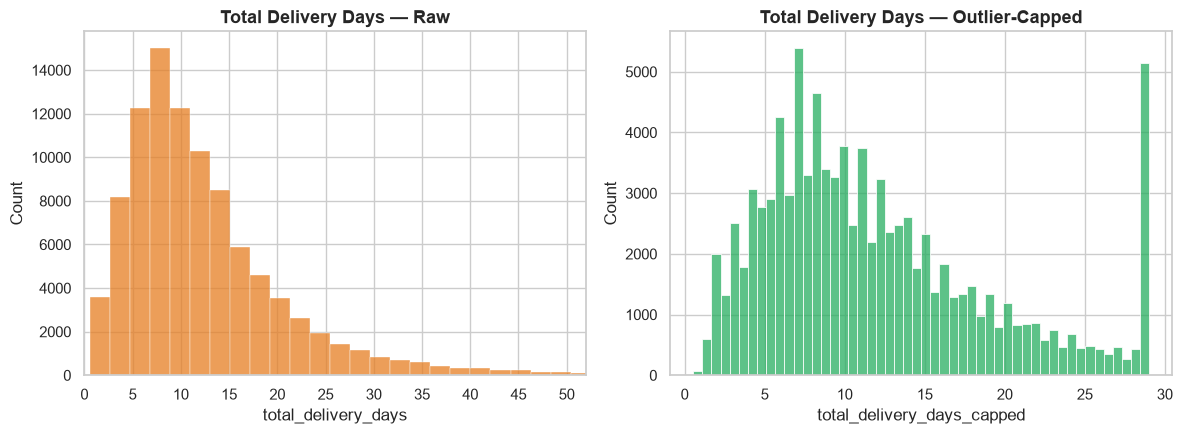

In [14]:
# Before vs after capping — visual sanity check on the headline metric
if "total_delivery_days" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.histplot(df["total_delivery_days"].dropna(), bins=100, ax=axes[0], color="#e67e22")
    axes[0].set_title("Total Delivery Days — Raw")
    axes[0].set_xlim(0, 52)
    axes[0].xaxis.set_major_locator(MultipleLocator(5))
    sns.histplot(df["total_delivery_days_capped"].dropna(), bins=50, ax=axes[1], color="#27ae60")
    axes[1].set_title("Total Delivery Days — Outlier-Capped")
    plt.tight_layout()
    plt.show()


### Checking if delivery days impacted review score

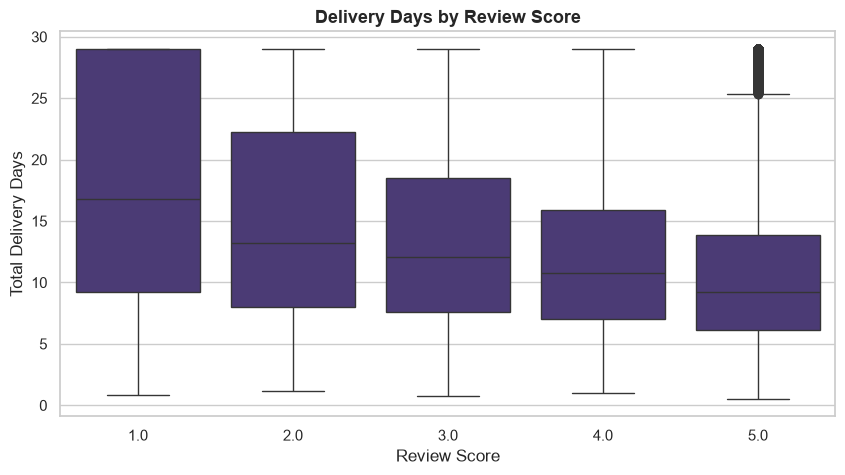

In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="review_score",
    y="total_delivery_days_capped"
)

plt.title("Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Total Delivery Days")
plt.show()

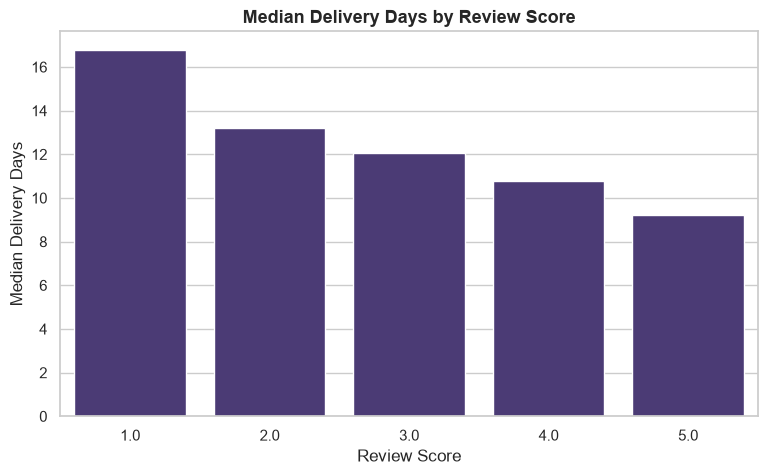

In [16]:
delivery_review_summary = (
    df.groupby("review_score")["total_delivery_days_capped"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

delivery_review_summary
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="review_score",
    y="total_delivery_days",
    estimator="median",
    errorbar=None
)

plt.title("Median Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Median Delivery Days")
plt.show()

### Univariate Analysis

C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\3258980863.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="order_status", order=order, palette="mako")


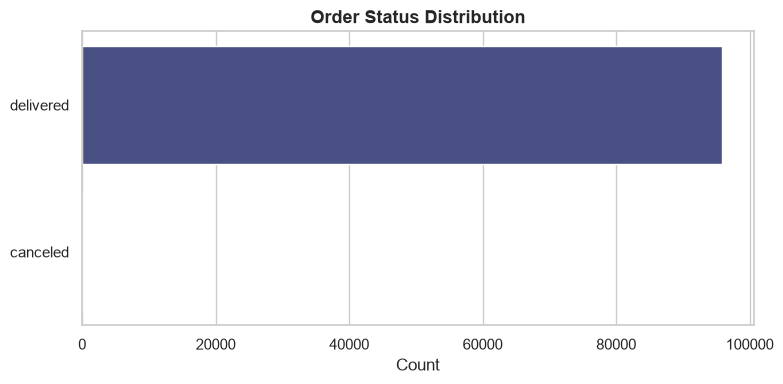

order_status
delivered    99.99
canceled      0.01
Name: pct, dtype: float64

In [17]:
## Categorical Variables
if "order_status" in df.columns:
    plt.figure(figsize=(8, 4))
    order = df["order_status"].value_counts().index
    sns.countplot(data=df, y="order_status", order=order, palette="mako")
    plt.title("Order Status Distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    display(df["order_status"].value_counts(normalize=True).mul(100).round(2).rename("pct"))


### Comprehensive Study of Customer State and Review Score

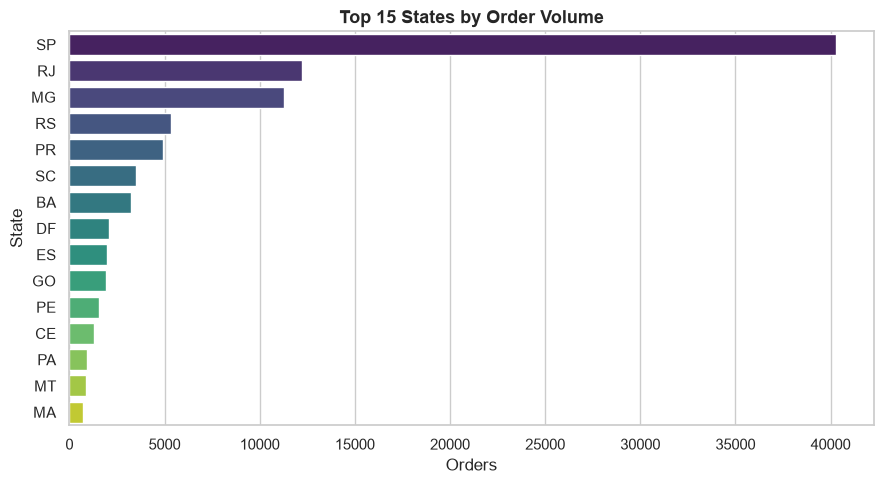

In [18]:
if "customer_state" in df.columns:
    top_states = df["customer_state"].value_counts().head(15)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=top_states.values, y=top_states.index, palette="viridis",hue=top_states.index)
    plt.title("Top 15 States by Order Volume")
    plt.xlabel("Orders")
    plt.ylabel("State")
    plt.tight_layout()
    plt.show();


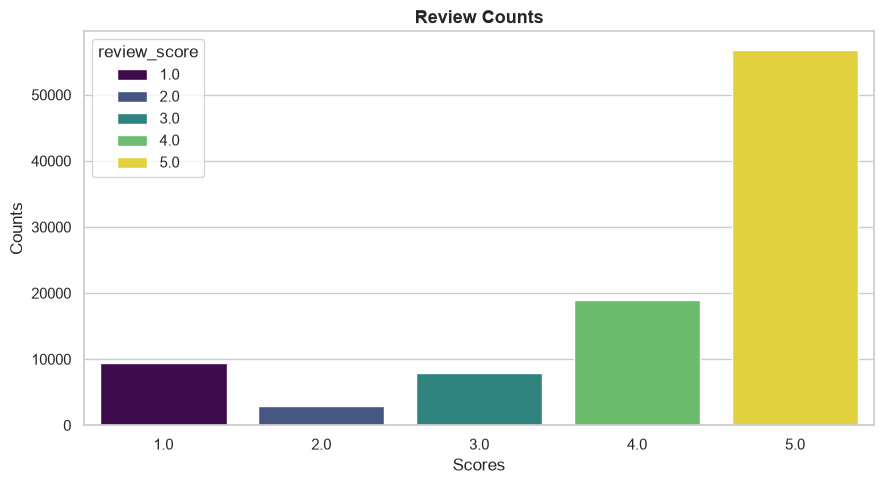

In [19]:
if "review_score" in df.columns:
    scores = df["review_score"].value_counts()
    plt.figure(figsize=(9, 5))
    sns.barplot(x=scores.index, y=scores.values, palette="viridis",hue=scores.index)
    plt.title("Review Counts")
    plt.xlabel("Scores")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()


### Numerical Variables

### Bivariate and MultiVariate Analysis

C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\1609579058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="review_score", y="delivery_vs_estimate_days_capped", palette="coolwarm")


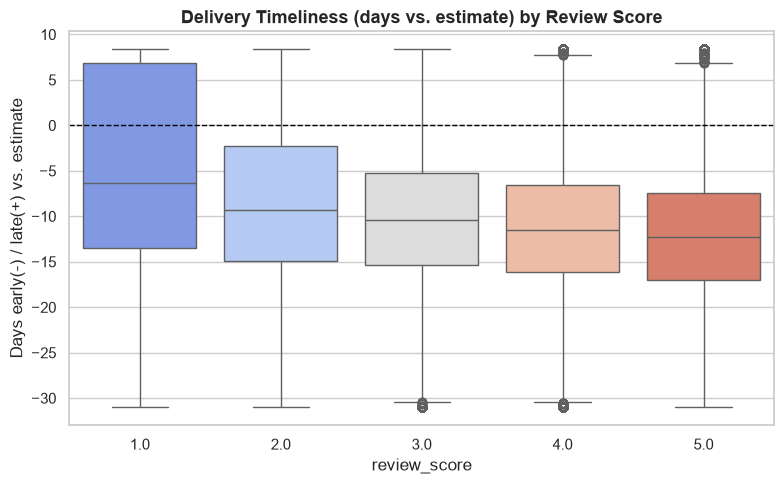

In [20]:
# Delivery lateness vs review score
if {"delivery_vs_estimate_days_capped", "review_score"}.issubset(df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="review_score", y="delivery_vs_estimate_days_capped", palette="coolwarm")
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Delivery Timeliness (days vs. estimate) by Review Score")
    plt.ylabel("Days early(-) / late(+) vs. estimate")
    plt.tight_layout()
    plt.show();


,mean,count
delivered_late,,
False,4.29,88168
True,2.57,7662


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\3397607860.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="delivered_late", y="review_score", palette="Set2", errorbar="ci")


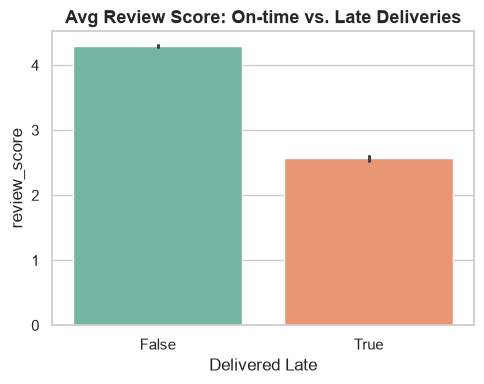

In [21]:
# Average review score by whether the order was delivered late
if {"delivered_late", "review_score"}.issubset(df.columns):
    late_review = df.groupby("delivered_late")["review_score"].agg(["mean", "count"]).round(2)
    display(late_review)

    plt.figure(figsize=(5, 4))
    sns.barplot(data=df, x="delivered_late", y="review_score", palette="Set2", errorbar="ci")
    plt.title("Avg Review Score: On-time vs. Late Deliveries")
    plt.xlabel("Delivered Late")
    plt.tight_layout()
    plt.show();


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\2069956298.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="review_risk_flag", y="review_score", palette="Spectral")


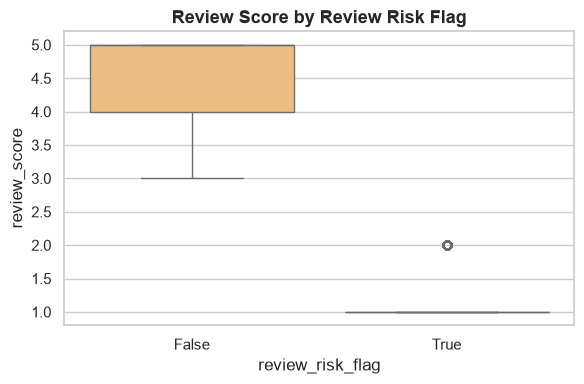

In [22]:
# review_risk_flag cross-check, if present
if {"review_risk_flag", "review_score"}.issubset(df.columns):
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="review_risk_flag", y="review_score", palette="Spectral")
    plt.title("Review Score by Review Risk Flag")
    plt.tight_layout()
    plt.show()


C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\3116217043.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_perf.values, y=state_perf.index, palette="flare")


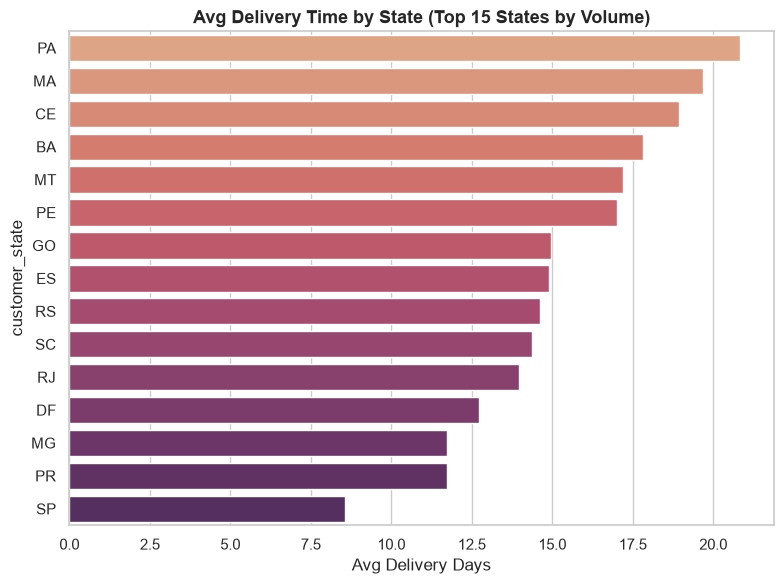

In [23]:
# Average delivery time by state (top 15 by volume) — logistics hot/cold spots
if {"customer_state", "total_delivery_days_capped"}.issubset(df.columns):
    top_states = df["customer_state"].value_counts().head(15).index
    state_perf = (
        df[df["customer_state"].isin(top_states)]
          .groupby("customer_state")["total_delivery_days_capped"]
          .mean().sort_values(ascending=False)
    )
    plt.figure(figsize=(8, 6))
    sns.barplot(x=state_perf.values, y=state_perf.index, palette="flare")
    plt.title("Avg Delivery Time by State (Top 15 States by Volume)")
    plt.xlabel("Avg Delivery Days")
    plt.tight_layout()
    plt.show()


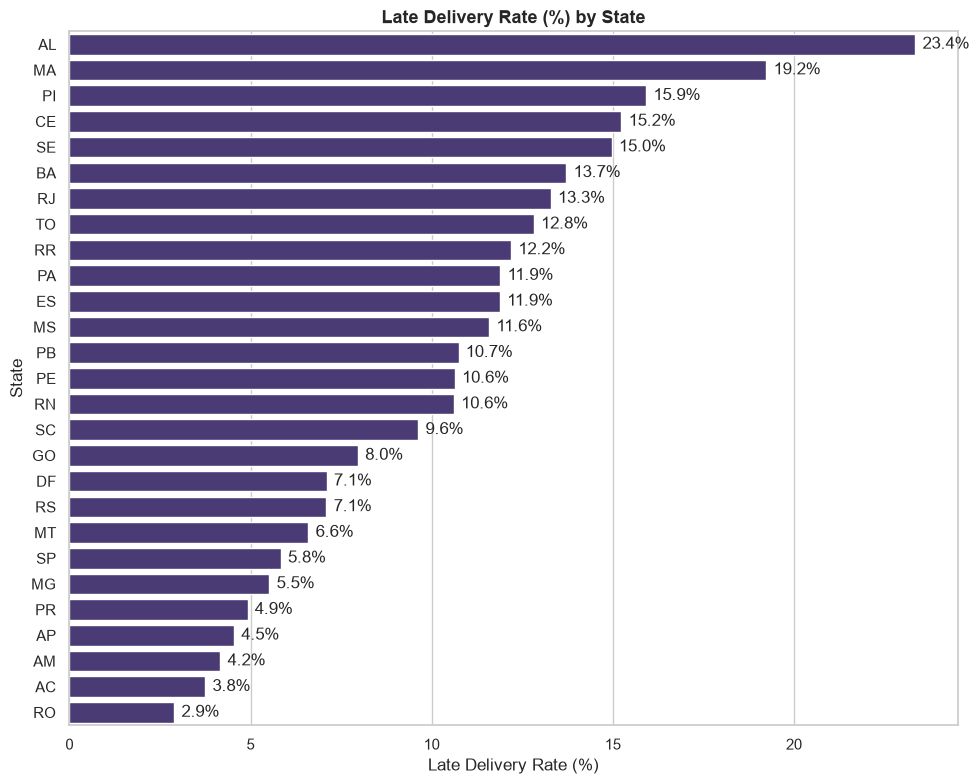

In [59]:
late_rate = (
    df.groupby("customer_state")["delivered_late"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=late_rate.values,
    y=late_rate.index
)

plt.title("Late Delivery Rate (%) by State")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("State")

# Add percentage labels
for i, value in enumerate(late_rate.values):
    plt.text(value + 0.2, i, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()

C:\Users\Hitesh\AppData\Local\Temp\ipykernel_19332\2585571688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_rate.values, y=late_rate.index, palette="rocket")


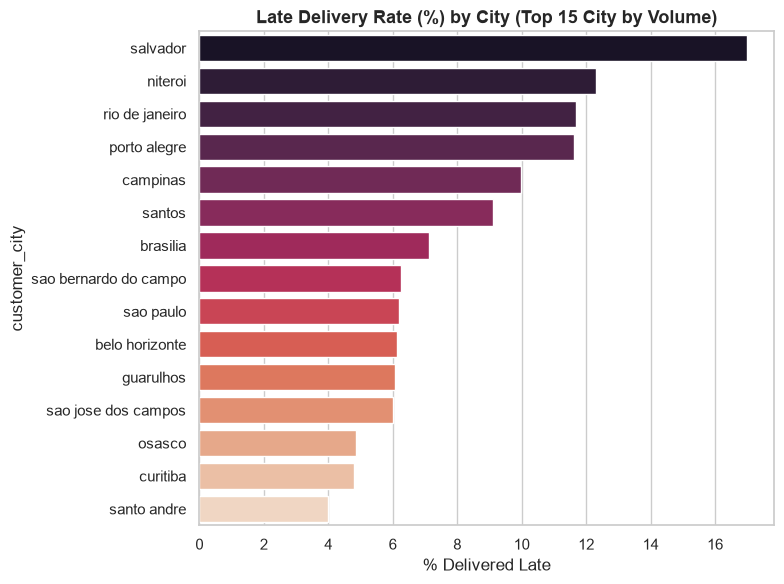

In [25]:
# Late-delivery rate by state
if {"customer_city", "delivered_late"}.issubset(df.columns):
    top_states = df["customer_city"].value_counts().head(15).index
    late_rate = (
        df[df["customer_city"].isin(top_states)]
          .groupby("customer_city")["delivered_late"]
          .mean().mul(100).sort_values(ascending=False)
    )
    plt.figure(figsize=(8, 6))
    sns.barplot(x=late_rate.values, y=late_rate.index, palette="rocket")
    plt.title("Late Delivery Rate (%) by City (Top 15 City by Volume)")
    plt.xlabel("% Delivered Late")
    plt.tight_layout()
    plt.show()


### Time Series Trends

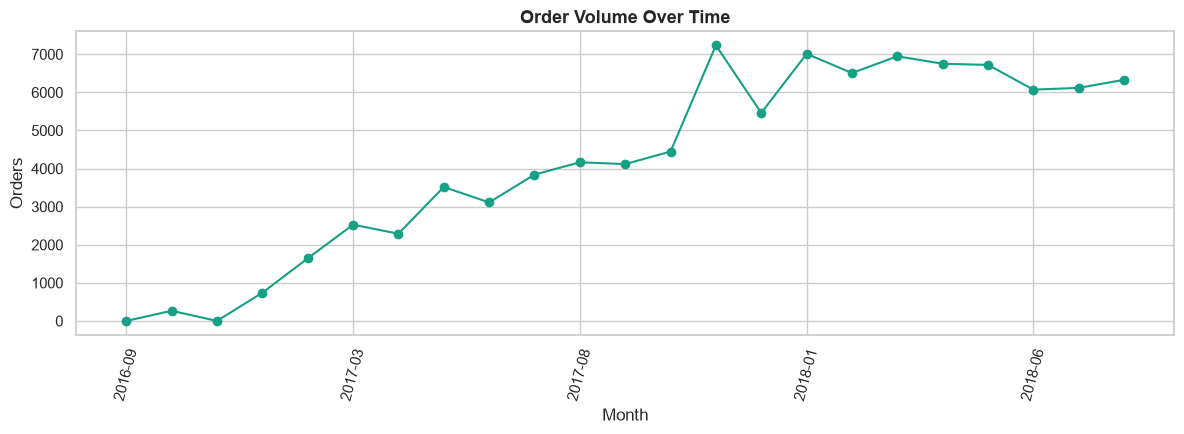

In [26]:
if "purchase_month" in df.columns:
    monthly = df.groupby("purchase_month").size()
    plt.figure(figsize=(12, 4.5))
    monthly.plot(kind="line", marker="o", color="#16a085")
    plt.title("Order Volume Over Time")
    plt.ylabel("Orders")
    plt.xlabel("Month")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()


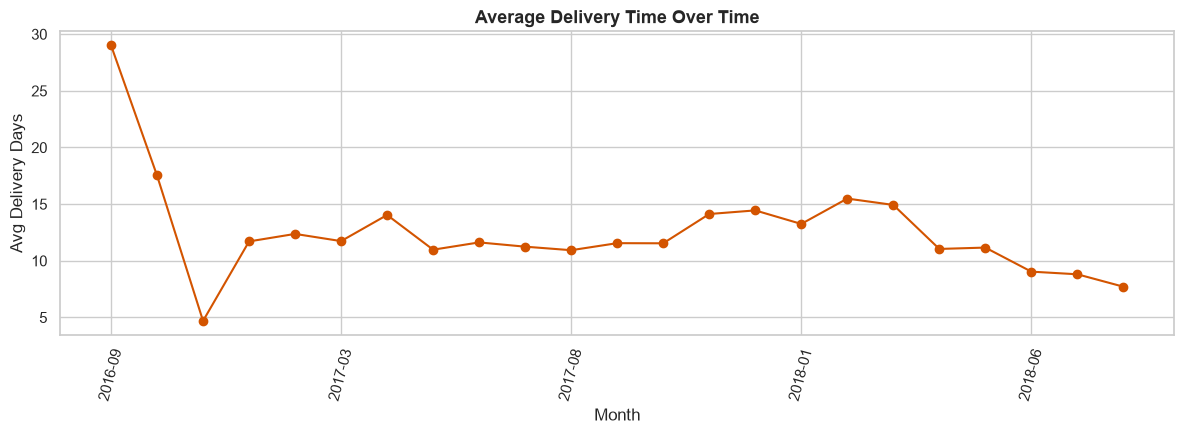

In [27]:
if {"purchase_month", "total_delivery_days_capped"}.issubset(df.columns):
    monthly_delivery = df.groupby("purchase_month")["total_delivery_days_capped"].mean()
    plt.figure(figsize=(12, 4.5))
    monthly_delivery.plot(kind="line", marker="o", color="#d35400")
    plt.title("Average Delivery Time Over Time")
    plt.ylabel("Avg Delivery Days")
    plt.xlabel("Month")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()


### Correlation Analysis

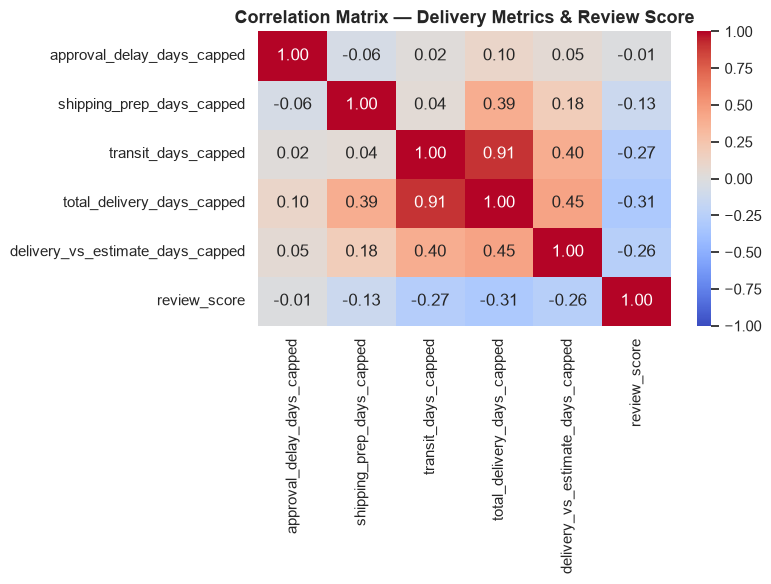

In [28]:
corr_cols = [c for c in [
    "approval_delay_days_capped", "shipping_prep_days_capped", "transit_days_capped",
    "total_delivery_days_capped", "delivery_vs_estimate_days_capped", "review_score",
] if c in df.columns]

if len(corr_cols) > 1:
    corr = df[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
    plt.title("Correlation Matrix — Delivery Metrics & Review Score")
    plt.tight_layout()
    plt.show()


In [29]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,review_score,review_risk_flag,approval_delay_days,shipping_prep_days,transit_days,total_delivery_days,delivery_vs_estimate_days,delivered_late,purchase_year,purchase_month,purchase_dow,purchase_hour,customer_zip_code_prefix_capped,review_score_capped,approval_delay_days_capped,shipping_prep_days_capped,transit_days_capped,total_delivery_days_capped,delivery_vs_estimate_days_capped,purchase_year_capped,purchase_hour_capped
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,4.0,False,0.007431,2.366493,6.062650,8.436574,-7.107488,False,2017,2017-10,Monday,10,3149,4.0,0.007431,2.366493,6.062650,8.436574,-7.107488,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,4.0,False,1.279745,0.462882,12.039410,13.782037,-5.355729,False,2018,2018-07,Tuesday,20,47813,4.0,1.279745,0.462882,12.039410,13.782037,-5.355729,2018,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,5.0,False,0.011505,0.204595,9.178113,9.394213,-17.245498,False,2018,2018-08,Wednesday,8,75265,5.0,0.011505,0.204595,9.178113,9.394213,-17.245498,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,5.0,False,0.012419,3.745833,9.450498,13.208750,-12.980069,False,2017,2017-11,Saturday,19,59296,5.0,0.012419,3.745833,9.450498,13.208750,-12.980069,2017,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,5.0,False,0.042940,0.893113,1.937824,2.873877,-9.238171,False,2018,2018-02,Tuesday,21,9195,5.0,0.042940,0.893113,1.937824,2.873877,-9.238171,2018,21


In [30]:
df.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score',
       'review_risk_flag', 'approval_delay_days', 'shipping_prep_days', 'transit_days', 'total_delivery_days',
       'delivery_vs_estimate_days', 'delivered_late', 'purchase_year', 'purchase_month', 'purchase_dow',
       'purchase_hour', 'customer_zip_code_prefix_capped', 'review_score_capped', 'approval_delay_days_capped',
       'shipping_prep_days_capped', 'transit_days_capped', 'total_delivery_days_capped',
       'delivery_vs_estimate_days_capped', 'purchase_year_capped', 'purchase_hour_capped'],
      dtype='str')

In [31]:
df_delay_state=df[df["approval_delay_days"]>0][["customer_state","delivery_vs_estimate_days"]]

<Axes: >

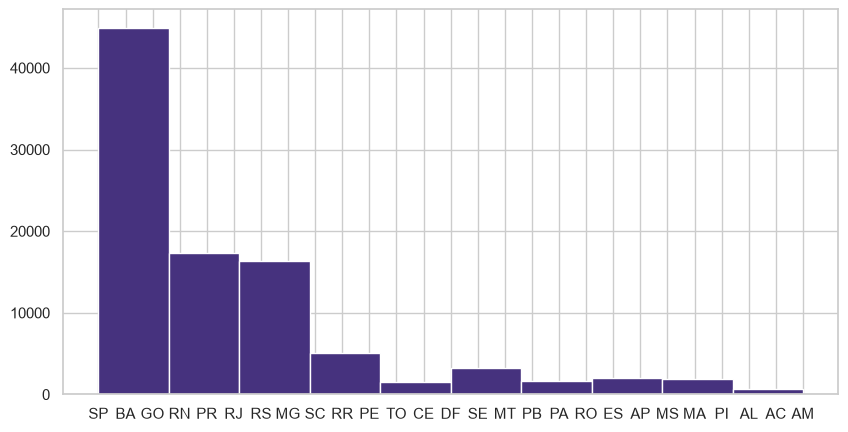

In [32]:
df_delay_state["customer_state"].hist()

In [33]:
df.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score',
       'review_risk_flag', 'approval_delay_days', 'shipping_prep_days', 'transit_days', 'total_delivery_days',
       'delivery_vs_estimate_days', 'delivered_late', 'purchase_year', 'purchase_month', 'purchase_dow',
       'purchase_hour', 'customer_zip_code_prefix_capped', 'review_score_capped', 'approval_delay_days_capped',
       'shipping_prep_days_capped', 'transit_days_capped', 'total_delivery_days_capped',
       'delivery_vs_estimate_days_capped', 'purchase_year_capped', 'purchase_hour_capped'],
      dtype='str')

In [40]:
late_count_by_state = (
    df[df["delivered_late"] == True]
    .groupby("customer_state")
    .size()
    .reset_index(name="late_count")
)

late_rate_by_state = (
    df.groupby("customer_state")["delivered_late"]
      .mean()
      .mul(100)
      .reset_index(name="late_rate")
)


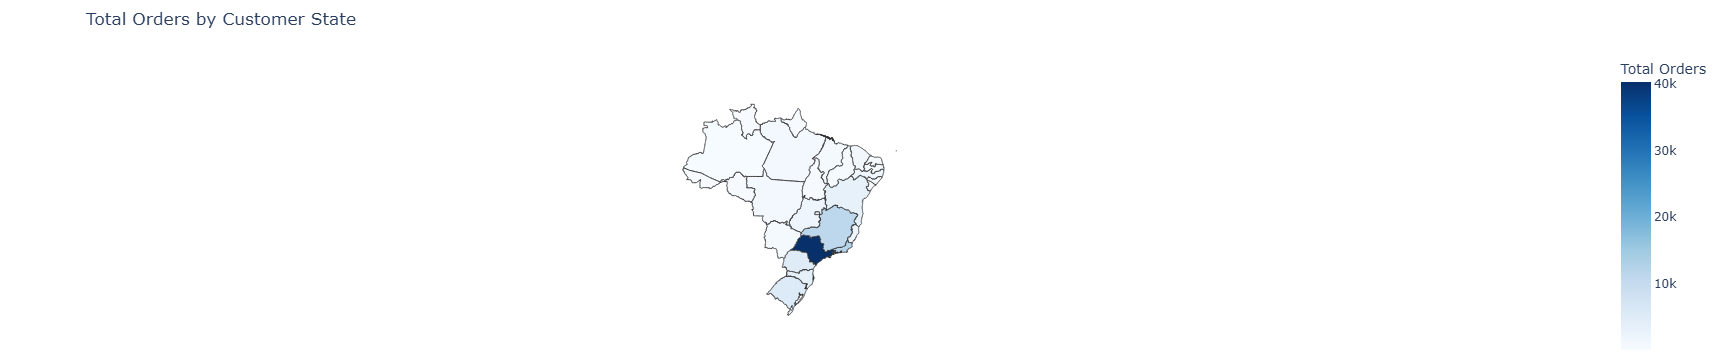

In [55]:
state_count=df["customer_state"].value_counts()
# Convert Series to DataFrame
state_count_df = state_count.reset_index()
state_count_df.columns = ["customer_state", "order_count"]

# Create choropleth
fig = px.choropleth(
    state_count_df,
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    locations="customer_state",
    featureidkey="properties.sigla",
    color="order_count",
    color_continuous_scale="Blues",
    scope="south america",
    labels={"order_count": "Total Orders"},
    title="Total Orders by Customer State"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

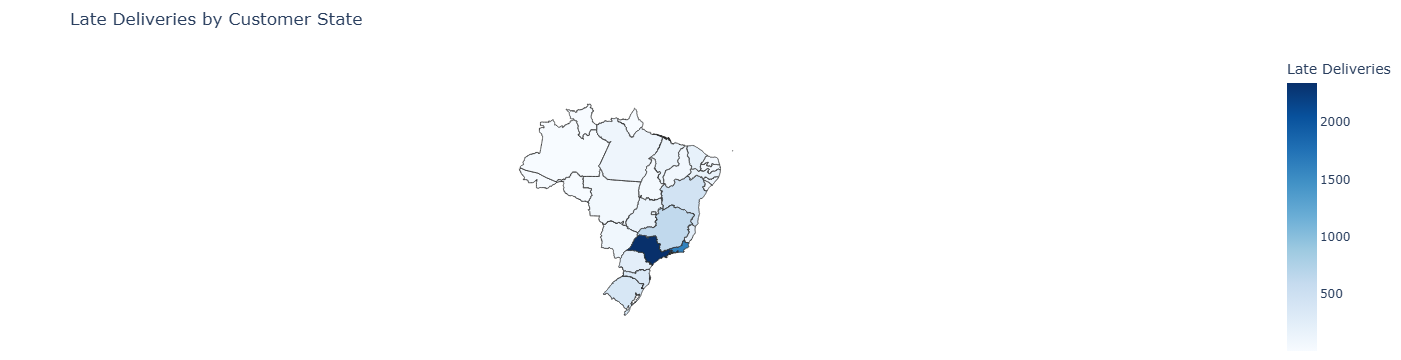

In [50]:


fig = px.choropleth(
    late_count_by_state,
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    locations="customer_state",
    featureidkey="properties.sigla",
    color="late_count",
    color_continuous_scale="Blues",
    scope="south america",
    labels={"late_count": "Late Deliveries"},
    title="Late Deliveries by Customer State"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

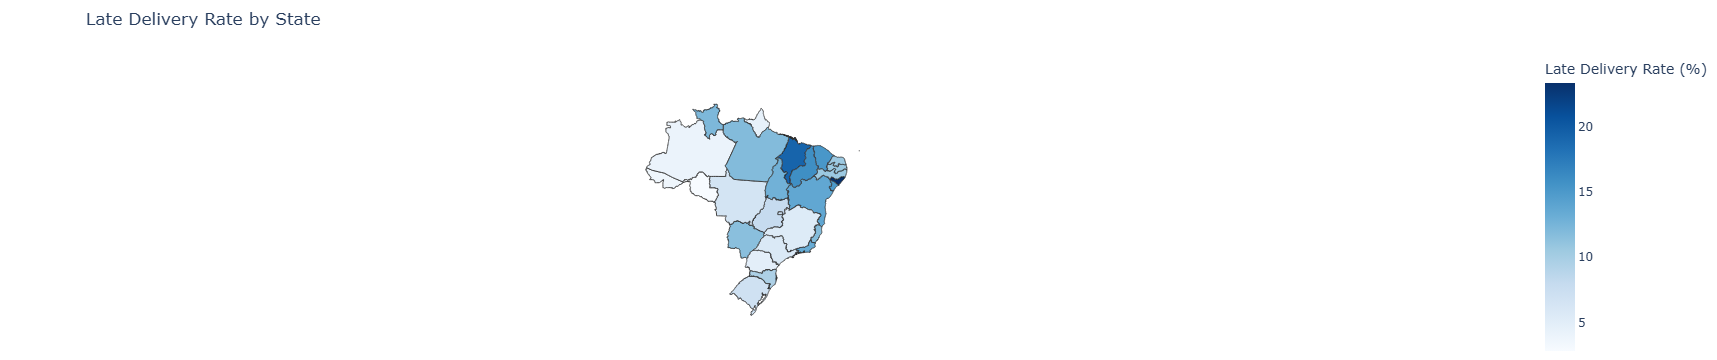

In [56]:
late_rate_by_state = (
    df.groupby("customer_state")["delivered_late"]
      .mean()
      .mul(100)
      .reset_index(name="late_rate")
)
fig = px.choropleth(
    late_rate_by_state,
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    locations="customer_state",
    featureidkey="properties.sigla",
    color="late_rate",
    color_continuous_scale="Blues",
    scope="south america",
    labels={"late_rate": "Late Delivery Rate (%)"},
    title="Late Delivery Rate by State"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0
})

fig.show()

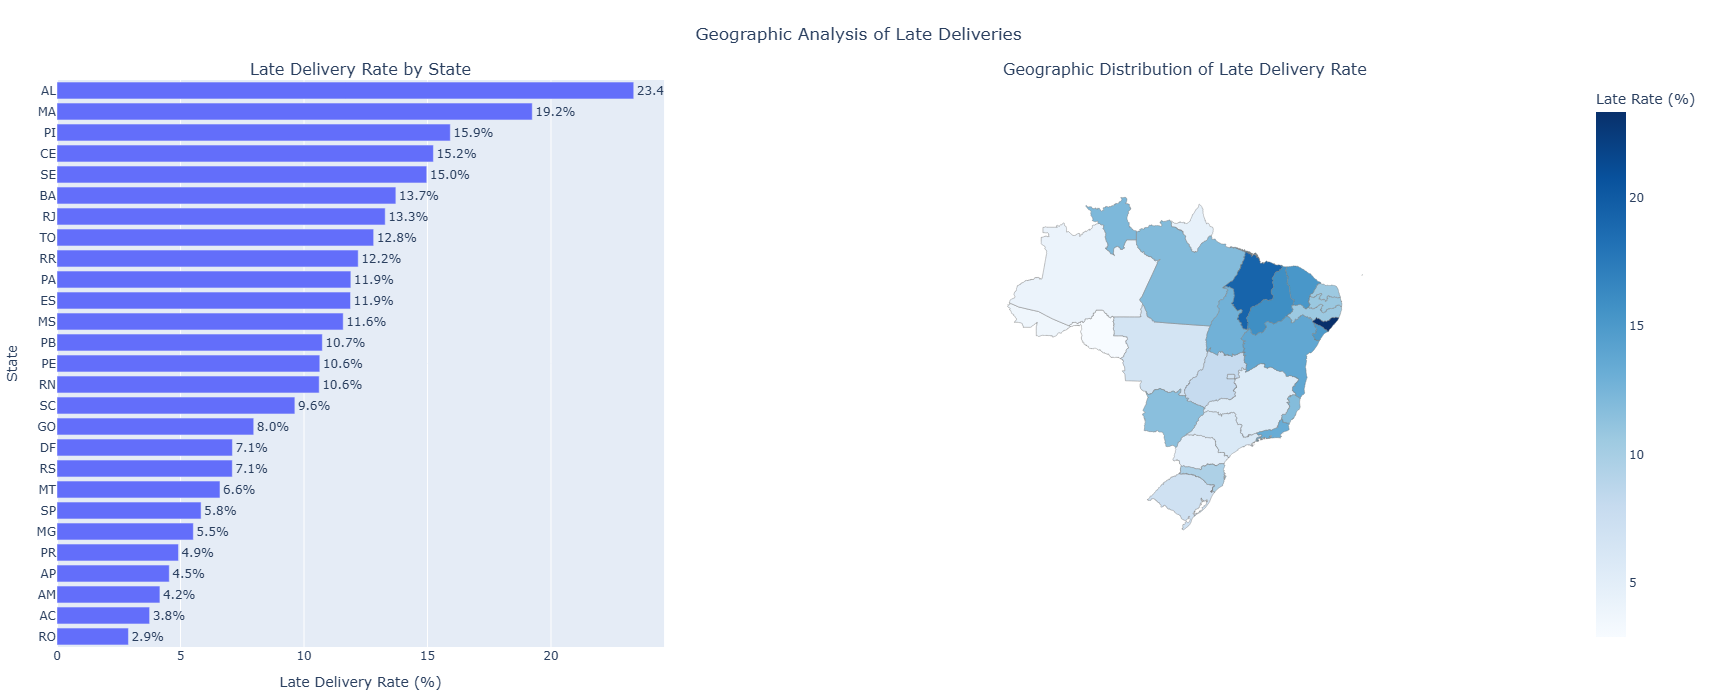

In [61]:


# ---------------------------------------------------------
# 1. Calculate late-delivery rate
# ---------------------------------------------------------
late_rate_by_state = (
    df.groupby("customer_state")["delivered_late"]
      .mean()
      .mul(100)
      .reset_index(name="late_rate")
)

# Sort for bar chart
late_rate_by_state = late_rate_by_state.sort_values(
    "late_rate", ascending=True
)

# ---------------------------------------------------------
# 2. Create Brazil choropleth
# ---------------------------------------------------------
geojson_url = (
    "https://raw.githubusercontent.com/codeforamerica/"
    "click_that_hood/master/public/data/brazil-states.geojson"
)

# ---------------------------------------------------------
# 3. Create subplots
# ---------------------------------------------------------
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[
        [{"type": "xy"}, {"type": "choropleth"}]
    ],
    column_widths=[0.45, 0.55],
    subplot_titles=(
        "Late Delivery Rate by State",
        "Geographic Distribution of Late Delivery Rate"
    )
)

# ---------------------------------------------------------
# 4. Bar chart
# ---------------------------------------------------------
fig.add_trace(
    go.Bar(
        x=late_rate_by_state["late_rate"],
        y=late_rate_by_state["customer_state"],
        orientation="h",
        text=late_rate_by_state["late_rate"].round(1).astype(str) + "%",
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Late Delivery Rate: %{x:.1f}%"
            "<extra></extra>"
        )
    ),
    row=1,
    col=1
)

# ---------------------------------------------------------
# 5. Choropleth
# ---------------------------------------------------------
fig.add_trace(
    go.Choropleth(
        geojson=geojson_url,
        locations=late_rate_by_state["customer_state"],
        z=late_rate_by_state["late_rate"],
        featureidkey="properties.sigla",
        colorscale="Blues",
        colorbar=dict(
            title="Late Rate (%)",
            x=1.02
        ),
        marker_line_color="gray",
        marker_line_width=0.5,
        hovertemplate=(
            "<b>%{location}</b><br>"
            "Late Delivery Rate: %{z:.1f}%"
            "<extra></extra>"
        )
    ),
    row=1,
    col=2
)

# ---------------------------------------------------------
# 6. Layout
# ---------------------------------------------------------
fig.update_layout(
    title={
        "text": "Geographic Analysis of Late Deliveries",
        "x": 0.5
    },
    height=700,
    width=1400,
    showlegend=False,
    margin=dict(l=20, r=80, t=80, b=20)
)

# Bar chart axes
fig.update_xaxes(
    title_text="Late Delivery Rate (%)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="State",
    row=1,
    col=1
)

# Map settings
fig.update_geos(
    fitbounds="locations",
    visible=False,
    row=1,
    col=2
)

fig.show()